In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

### 1. Import libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

### Loaded dataset

In [4]:
from src.data import load_csv

In [5]:
df = load_csv('C:/Users/Sarthak/Dev/projects/Learning ML through Projects/LR Bike Project/data/hour.csv')


In [6]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[ns]
 1   season      17379 non-null  int64         
 2   yr          17379 non-null  int64         
 3   mnth        17379 non-null  int64         
 4   hr          17379 non-null  int64         
 5   holiday     17379 non-null  int64         
 6   weekday     17379 non-null  int64         
 7   workingday  17379 non-null  int64         
 8   weathersit  17379 non-null  int64         
 9   temp        17379 non-null  float64       
 10  atemp       17379 non-null  float64       
 11  hum         17379 non-null  float64       
 12  windspeed   17379 non-null  float64       
 13  cnt         17379 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(9)
memory usage: 1.9 MB


In [8]:
df.describe()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000
std,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599


### Sorting by dteday and then hr for chronology. 

In [9]:
df = df.sort_values(by=['dteday', 'hr'], axis=0)

In [10]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


CATEGORICAL COLUMNS ARE: Season, Weathersit, hr

<Figure size 900x900 with 0 Axes>

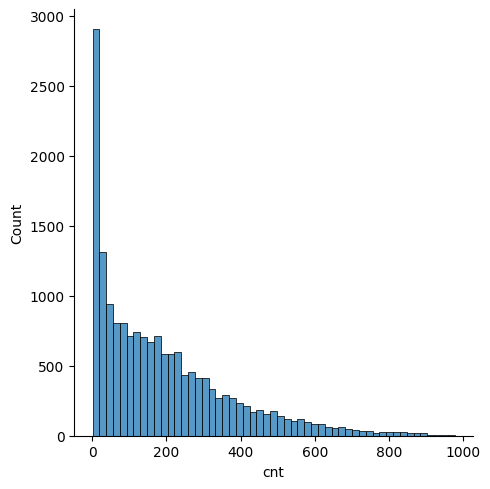

In [11]:
def distribution(df, column):
    plt.figure(figsize=(9,9))
    sea.displot(data=df, x=column)
    plt.show()

distribution(df, 'cnt')

The `cnt` is highly left skewed, which tells us that the count of bikes rented is left skewed mostly from 0 to 2500

Correction: the data is righ skewed: skewness == where tail of data is not the bulk data, therefore it is right skewed

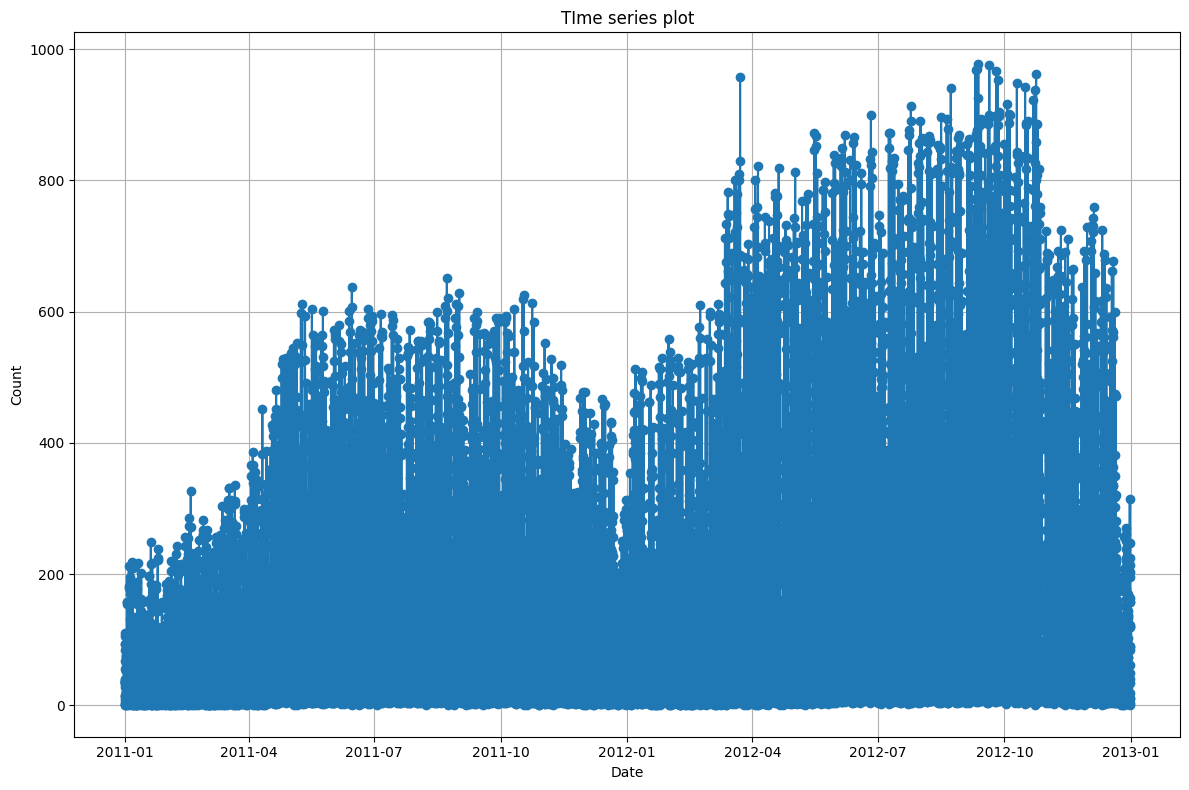

In [12]:
plt.figure(figsize=(12, 8))
plt.plot(df['dteday'], df['cnt'] ,marker='o', linestyle='-')
plt.title("TIme series plot")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
def make_scatterplot(x, y, df, hue=None):
    plt.figure(figsize=(4,5))
    sea.scatterplot(x=x, y=y, data=df, hue=hue)
    plt.title(f"{x} and {y} Scatterplot")
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    plt.tight_layout()
    plt.show()

    return None


def make_barplot(x, df, y=None):
    plt.figure(figsize=(5,6))
    sea.barplot(data=df, x=x, y=y)
    plt.title(f"{x} and {y} barplot")
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    plt.show()

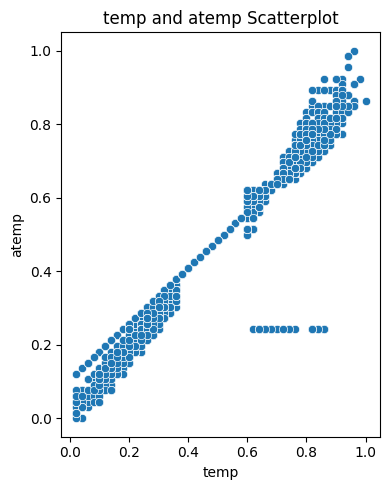

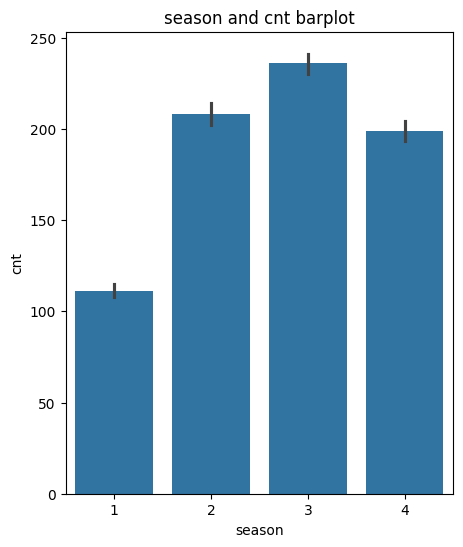

In [14]:
make_scatterplot('temp', 'atemp', df)

make_barplot('season', df, 'cnt')

As we can see temp and atemp are nearly very similiar.

In [15]:
num_cols_for_bxplt = df.drop(columns=['season', 'mnth', 'yr', 'season', 'weathersit', 'hr', 'holiday', 'weekday', 'workingday', 'dteday'])
num_cols_for_bxplt

,temp,atemp,hum,windspeed,cnt
0,0.24,0.2879,0.81,0.0000,16
1,0.22,0.2727,0.80,0.0000,40
2,0.22,0.2727,0.80,0.0000,32
3,0.24,0.2879,0.75,0.0000,13
4,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...
17374,0.26,0.2576,0.60,0.1642,119
17375,0.26,0.2576,0.60,0.1642,89
17376,0.26,0.2576,0.60,0.1642,90
17377,0.26,0.2727,0.56,0.1343,61


### BOXPLOT for continuous values: [temp, atemp, humidity, windspeed, cnt]

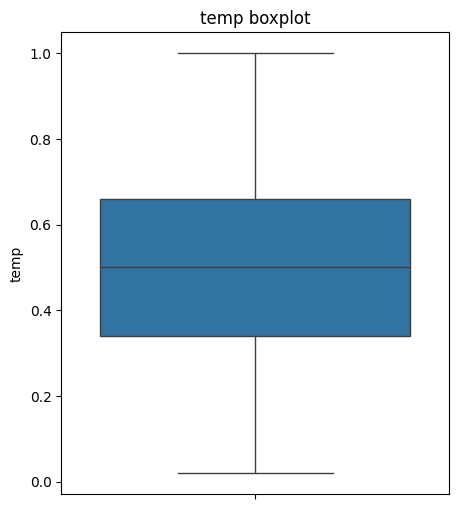

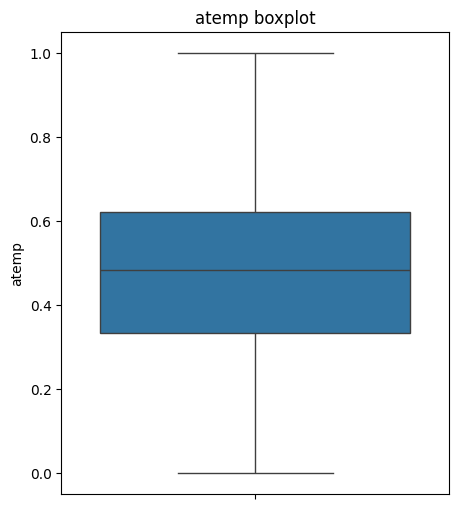

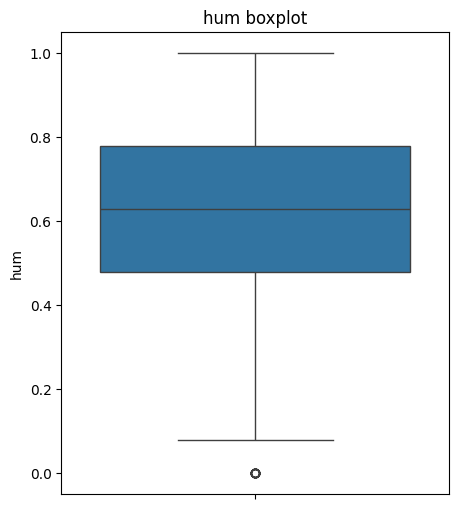

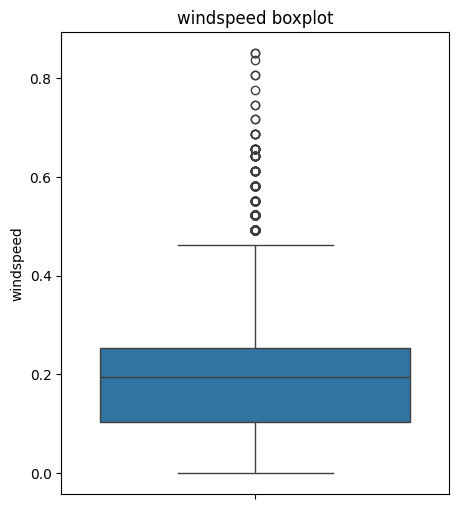

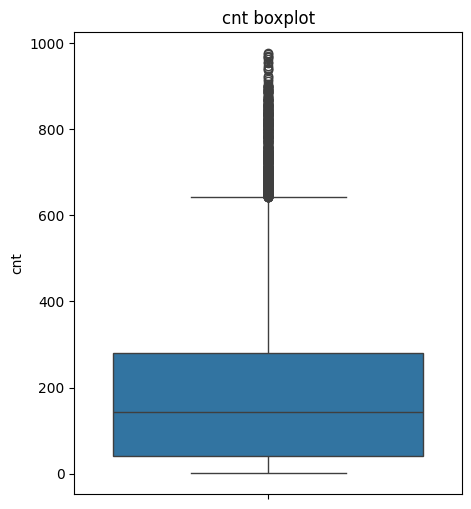

In [16]:
def boxplots(num_cols):
    for cols in num_cols:
        plt.figure(figsize=(5,6))
        sea.boxplot(data=num_cols, y=cols)
        plt.title(f"{cols} boxplot")
        plt.show()

boxplots(num_cols=num_cols_for_bxplt)

As we can see major outliers in CNT and windspeed can be crucial for our understanding of data, more cnt on festive seasons and windspeed high on hurricanes and typhoons or bad weather okay.

In [17]:
for s in df['season'].unique():
    sub = df[df['season']==s]
    print(s, sub['temp'].corr(sub['cnt']))

1 0.4462422003387881
2 0.4078116528439961
3 0.34527403842100535
4 0.341742766610272


In [18]:
for h in df['hr'].unique():
    sub = df[df['hr'] == h]
    print(h, sub['temp'].corr(sub['cnt']))

0 0.41761783618348136
1 0.2732817287732973
2 0.22685461758787343
3 0.22397856949121603
4 0.40718049546529145
5 0.41233731265397777
6 0.4078286992920506
7 0.3685962264597265
8 0.2974093473708205
9 0.4275427131655221
10 0.42067043421842126
11 0.4070665563130961
12 0.4126789878544944
13 0.3962761660650458
14 0.3784654677138089
15 0.3881622601629129
16 0.5518612912669429
17 0.587931522617859
18 0.6013338196980911
19 0.67776846638315
20 0.7101472945891419
21 0.7204207794394328
22 0.7006422092247667
23 0.6077455617681111


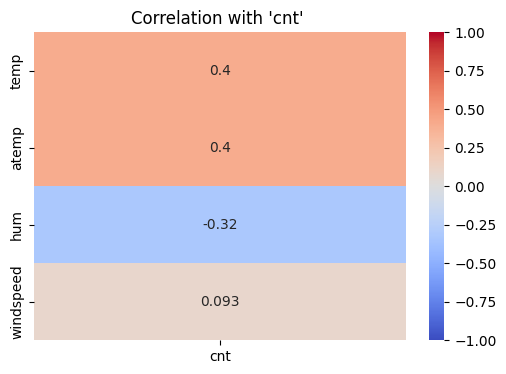

In [19]:
num_cols_for_bxplt = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
continous_df = df[num_cols_for_bxplt]
corr_matrix = continous_df.corr()[['cnt']].drop('cnt')
plt.figure(figsize=(6,4))
sea.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title(f"Correlation with 'cnt' ")
plt.show()

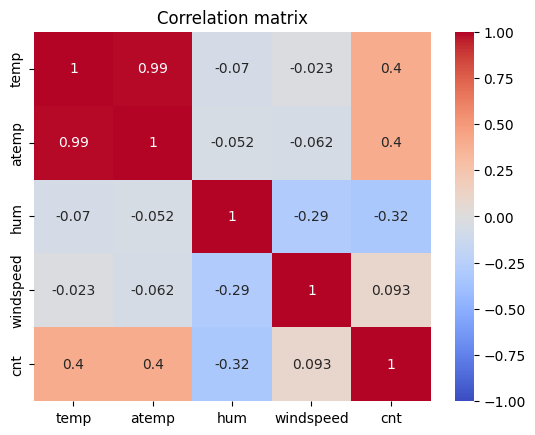

In [20]:
corr_mat = continous_df.corr()
sea.heatmap(corr_mat, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title("Correlation matrix")
plt.show()

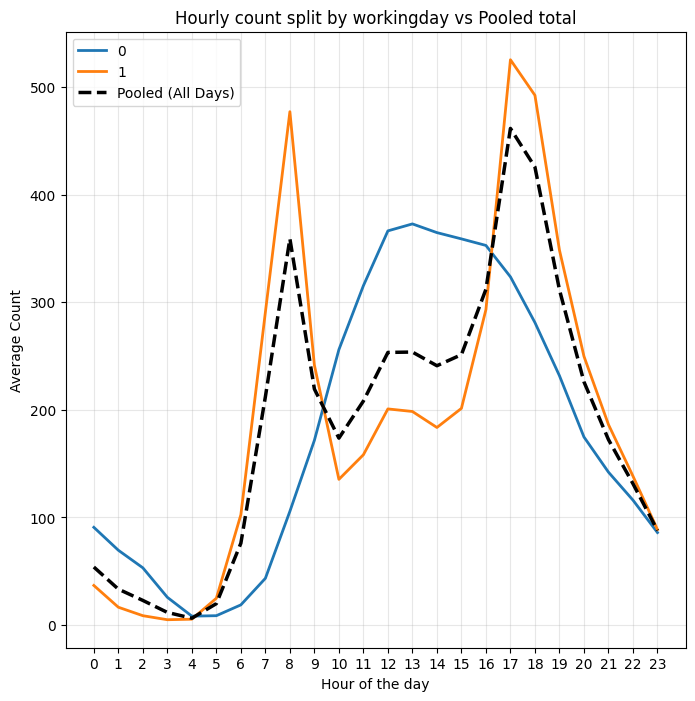

In [22]:
df_grouped = df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

df_pooled = df.groupby('hr')['cnt'].mean().reset_index()


plt.figure(figsize=(8,8))
sea.lineplot(data=df_grouped, x='hr', y='cnt', hue='workingday', linewidth=2)
sea.lineplot(data=df_pooled,x='hr', y='cnt', color='black', linestyle='--', linewidth=2.5, label='Pooled (All Days)')

plt.title("Hourly count split by workingday vs Pooled total")
plt.xlabel("Hour of the day")
plt.ylabel("Average Count")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

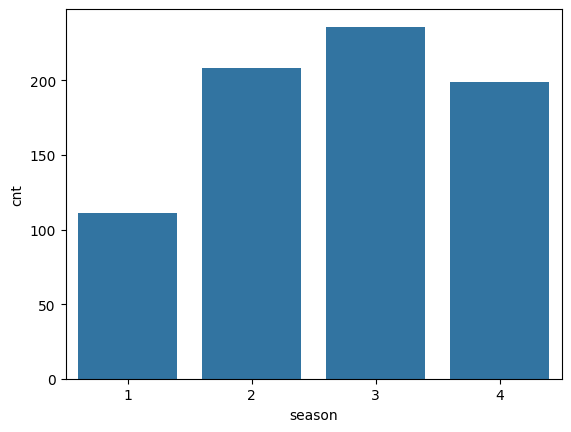

In [24]:
df_seasons = df.groupby('season')['cnt'].mean().reset_index()

sea.barplot(data=df_seasons, x='season', y='cnt')
plt.show()

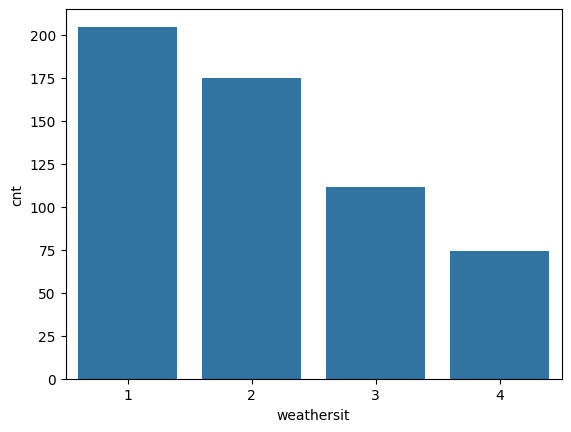

In [25]:
df_weathersit = df.groupby('weathersit')['cnt'].mean().reset_index()
sea.barplot(data=df_weathersit, x='weathersit', y='cnt')
plt.show()

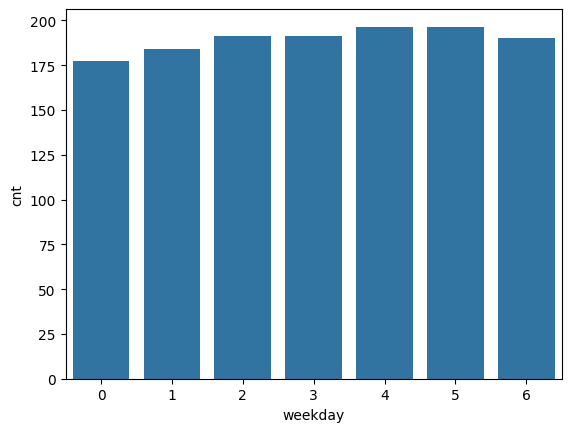

In [26]:
df_weekday = df.groupby('weekday')['cnt'].mean().reset_index()
sea.barplot(data=df_weekday, x='weekday', y='cnt')
plt.show()

### Today I learned:
1. EDA is more than plotting graphs, it is understanding about what graphs would give us more knowledge about our data, it is not memorising `scatterplot` syntax but about how scatterplot can help us undertsand the trend and relationship

2. Interpreting the graphs, as we can see our `cnt` is left skewed which is not a good thing when it comes for predicting using a linear model, `temp and atemp` are   `0.99` correlated meaning they are redundant columns, how time of the day: `hr` `season` `weathersituation` and `weekday` can affect the `cnt` dependent variable.

3. Leanred how to interpret the corellation, howw to use r = cos(theta) to find the angle between two columns.

4. The underlying SIMPSON PARADOX in cnt hr and weekday: how the trend is different in ISOLATION and when POOLED together, the differnence is clearly visible and which can help us understand the relations much more accurately.

5. The outliers in continuous variables like high windspeed and low humidity is the factor to consider while calculating the cnt

6. The stepping stonefor this prohject is lead, how to perform EDA in VSCODE by defining functions and everything.

7. I enjoyed it, with my wholeheart it was fun to plot time series graph and heatmap and then interpreting them like a child. 

8. GOOD NIGHT FRIEND!